# Learning Detection Comparison (Strategies 1–3)

This notebook:
1) Runs Bayesian strategy analysis for multiple strategies (Figure 1-style)
2) Selects the dominant rule strategy automatically (go_left/go_right/go_cued)
3) Computes learning trial using:
   - Strategy 1: Sequence criterion
   - Strategy 2: Sequence + Precision
   - Strategy 3: Expert (posterior excludes chance)
4) Plots all learning trials on the rule-strategy MAP plot

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials
from scipy.stats import beta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)

# We will detect learning per RULE BLOCK, not across the entire session,
# because the task rule changes multiple times.
# Therefore "until end" means: until the end of the current block.

In [2]:
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "go_uncued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]

rule_to_strategy = {
    "go right": "go_right",
    "go to the lit arm": "go_cued",
    "go left": "go_left",
    "go to the dark arm": "go_uncued"
}



strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")

In [3]:
alpha0, beta0 = set_priors(prior_type)

Output_collection = {}
event_totals = {}

for s in strategies:
    Output_collection[s] = pd.DataFrame(columns=[
        "Alpha", "Beta",
        "MAPprobability", "Precision",
        "Alpha_interpolated", "Beta_interpolated",
        "MAPprobability_interpolated", "Precision_interpolated"
    ])
    event_totals[s] = {"success_total": 0, "failure_total": 0}

In [4]:
for trial in range(len(TestData)):

    rows_of_data = TestData.iloc[0:trial+1]

    for s in strategies:

        trial_type = strategy_functions[s](rows_of_data)

        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[s]["success_total"],
            event_totals[s]["failure_total"],
            alpha0,
            beta0
        )

        event_totals[s]["success_total"] = success_total
        event_totals[s]["failure_total"] = failure_total

        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }

        if trial > 0:
            previous_trials_data = Output_collection[s].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[s]

        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )

        Output_collection[s] = pd.concat(
            [Output_collection[s], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_48878/2211875573.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[s] = pd.concat(


In [5]:
# --- Get block boundaries (rule changes) ---
if "RuleChangeTrials" in TestData.columns:
    # e.g. per-trial vector; unique trial indices where rule changes
    block_boundaries = list(
        TestData.index[TestData["RuleChangeTrials"] == 1])
elif "NewSessionTrials" in TestData.columns:
    block_boundaries = sorted(set(TestData["NewSessionTrials"].dropna().astype(int).tolist()))
else:
    block_boundaries = []

# Remove 0 and out-of-range values if they exist
block_boundaries = [b for b in block_boundaries if 0 < b < len(TestData)]

In [6]:
# ------------------------------------------------
# Detect rule blocks and their target strategies
# ------------------------------------------------

block_starts = [0] + block_boundaries
block_ends = block_boundaries + [len(TestData)]

# Try to read rule labels from dataset
if "TargetRule" in TestData.columns:
    block_labels = [TestData.iloc[s]["TargetRule"] for s in block_starts]
else:
    # fallback labels
    block_labels = [
        "go right",
        "go to the lit arm",
        "go left",
        "go to the dark arm"
    ][:len(block_starts)]

print("Block labels:", block_labels)

# Map rule → strategy

block_target_strategies = [
    rule_to_strategy[label] for label in block_labels
]

print("Block target strategies:", block_target_strategies)

Block labels: ['go right', 'go to the lit arm']
Block target strategies: ['go_right', 'go_cued']


In [7]:
print("block boundaries:", block_boundaries)
print("block starts:", block_starts)
print("block ends:", block_ends)

block boundaries: [170]
block starts: [0, 170]
block ends: [170, 734]


In [8]:
def learning_trial_sequence_per_block(MAP,
                                      block_boundaries,
                                      chance=0.5,
                                      min_trials=5):
    """
    Sequence criterion per block:
    For each rule block, find first trial t such that
    MAP[t:block_end] > chance for all remaining trials,
    with at least min_trials remaining.
    min_trials guards against spurious detections caused by a
    small number of trials at a session boundary happening to
    exceed chance.
    """

    MAP = np.asarray(MAP)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(MAP)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            remaining = MAP[t:end]
            if len(remaining) >= min_trials and np.all(remaining > chance):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [9]:
def learning_trial_sequence_precision_per_block(Output_collection,
                                                target,
                                                others,
                                                block_boundaries,
                                                chance=0.5,
                                                min_trials=5):
    """
    Strategy 2 per block:
    - MAP(target) stays > chance until block end, with at least min_trials remaining
    - AND Precision(target) at learning trial >= max Precision(others)
    """

    MAP_t  = Output_collection[target]["MAPprobability"].values
    PREC_t = Output_collection[target]["Precision"].values

    PREC_others = np.vstack([
        Output_collection[o]["Precision"].values for o in others
    ])

    max_other = PREC_others.max(axis=0)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(MAP_t)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            remaining = MAP_t[t:end]
            if (len(remaining) >= min_trials and
                np.all(remaining > chance) and
                PREC_t[t] >= max_other[t]):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [10]:
from scipy.stats import beta

def learning_trial_expert_per_block(Output_collection,
                                    target,
                                    block_boundaries,
                                    chance=0.5,
                                    prob_thresh=0.95):
    """
    Strategy 3 per block:
    P(p > chance) >= prob_thresh for all trials t:block_end
    """

    A = Output_collection[target]["Alpha"].values
    B = Output_collection[target]["Beta"].values

    p_gt = 1.0 - beta.cdf(chance, A, B)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(p_gt)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            if np.all(p_gt[t:end] >= prob_thresh):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [11]:
if "RuleChangeTrials" in TestData.columns:
    block_boundaries = sorted(
        set(TestData["RuleChangeTrials"].dropna().astype(int))
    )
else:
    block_boundaries = []

In [12]:
t1_list = []
t2_list = []
t3_list = []

min_trials = 5  # minimum remaining trials required to declare learning

for start, end, strategy in zip(block_starts, block_ends, block_target_strategies):

    MAP = Output_collection[strategy]["MAPprobability"].values
    block_MAP = MAP[start:end]

    # Strategy 1: Sequence criterion
    lt1 = None
    for t in range(len(block_MAP)):
        remaining = block_MAP[t:]
        if len(remaining) >= min_trials and np.all(remaining > 0.5):
            lt1 = start + t
            break
    t1_list.append(lt1)

    # Strategy 2: Sequence + Precision
    PREC = Output_collection[strategy]["Precision"].values

    others = [s for s in rule_strategies if s != strategy]

    PREC_others = np.vstack([
        Output_collection[o]["Precision"].values
        for o in others
    ])

    max_other = PREC_others.max(axis=0)

    lt2 = None
    for t in range(start, end):
        remaining = MAP[t:end]
        if (len(remaining) >= min_trials and
            np.all(remaining > 0.5) and
            PREC[t] >= max_other[t]):
            lt2 = t
            break
    t2_list.append(lt2)

    # Strategy 3: Expert criterion
    A = Output_collection[strategy]["Alpha"].values
    B = Output_collection[strategy]["Beta"].values

    p_gt = 1 - beta.cdf(0.5, A, B)

    lt3 = None
    for t in range(start, end):
        if np.all(p_gt[t:end] >= 0.95):
            lt3 = t
            break
    t3_list.append(lt3)

In [13]:
print("S1:", t1_list)
print("S2:", t2_list)
print("S3:", t3_list)

S1: [22, 693]
S2: [26, 700]
S3: [67, 731]


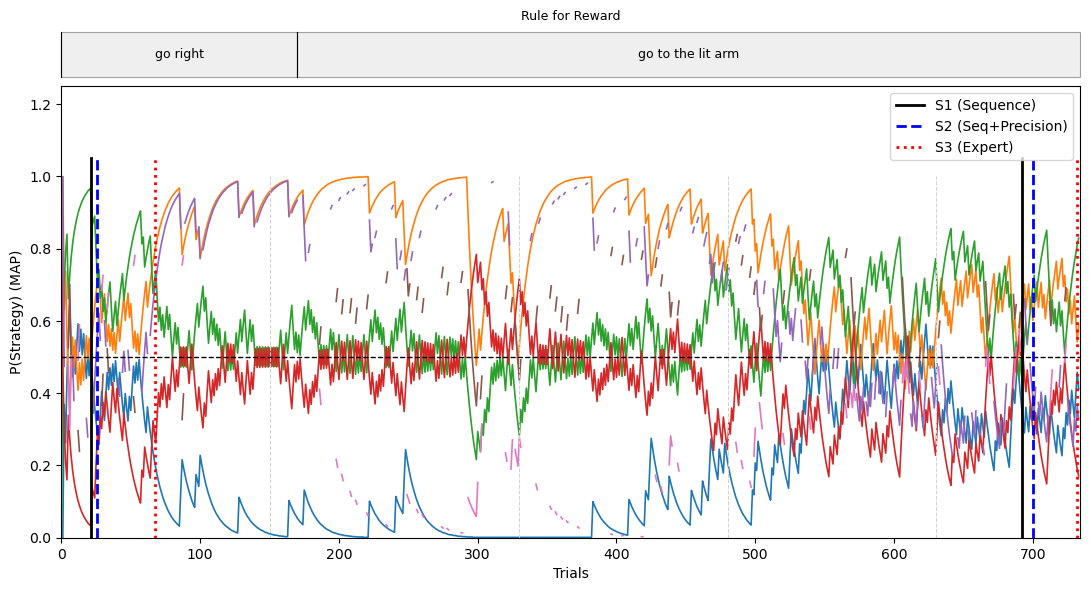

In [14]:
plt.figure(figsize=(11, 6))

# ---------------------------------------
# 1) Plot MAP curves
# ---------------------------------------
for s in strategies:
    plt.plot(Output_collection[s]["MAPprobability"],
             linewidth=1.2,
             label=s)

plt.axhline(0.5,
            linestyle="--",
            linewidth=1.0,
            color="black",
            label="chance = 0.5")

# ---------------------------------------
# 2) Plot learning trials (offset to avoid overlap)
# ---------------------------------------

offset = 0.6  # small horizontal shift

offset = 0.6
ymax = 1.05

# Strategy 1
for lt in t1_list:
    if lt is not None:
        plt.plot([lt - offset, lt - offset], [0, ymax],
                 color="black", linewidth=2)

# Strategy 2
for lt in t2_list:
    if lt is not None:
        plt.plot([lt, lt], [0, ymax],
                 color="blue", linestyle="--", linewidth=2)

# Strategy 3
for lt in t3_list:
    if lt is not None:
        plt.plot([lt + offset, lt + offset], [0, ymax],
                 color="red", linestyle=":", linewidth=2)
# ---------------------------------------
# 3) Plot rule structure (top shading)
# ---------------------------------------


# ---------------------------------------
# 4) Formatting
# ---------------------------------------
plt.xlabel("Trials")
plt.ylabel("P(Strategy) (MAP)")
plt.xlim(0, len(TestData))
plt.ylim(0, 1.25)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color="black", lw=2),
    Line2D([0], [0], color="blue", lw=2, linestyle="--"),
    Line2D([0], [0], color="red", lw=2, linestyle=":")
]

plt.legend(
    custom_lines,
    ["S1 (Sequence)", "S2 (Seq+Precision)", "S3 (Expert)"],
    loc="upper right"
)

plotSessionStructure(TestData, block_labels=block_labels)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()



In [15]:
df_results = pd.DataFrame({
    "Block": block_labels,
    "Strategy": block_target_strategies,
    "Sequence (S1)": t1_list,
    "Seq+Precision (S2)": t2_list,
    "Expert (S3)": t3_list
})

df_results

,Block,Strategy,Sequence (S1),Seq+Precision (S2),Expert (S3)
0,go right,go_right,22,26,67
1,go to the lit arm,go_cued,693,700,731


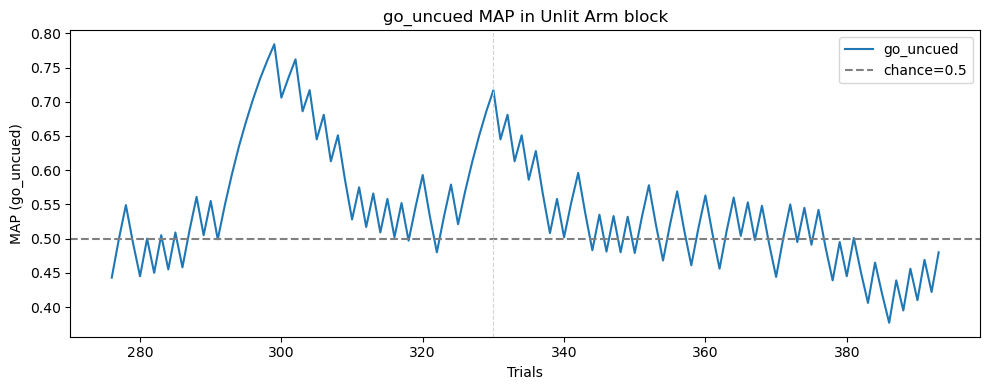

Trials where MAP > 0.5: 78 out of 118
Last trial MAP: 0.48


In [16]:
import matplotlib.pyplot as plt

start, end = 276, 394
uncued_MAP = Output_collection["go_uncued"]["MAPprobability"].values[start:end]

plt.figure(figsize=(10, 4))
plt.plot(range(start, end), uncued_MAP, label="go_uncued")
plt.axhline(0.5, color="grey", linestyle="--", label="chance=0.5")

# Session boundaries in this block
if "NewSessionTrials" in TestData.columns:
    session_bounds = list(TestData.index[(TestData["NewSessionTrials"] == 1) & 
                                          (TestData.index >= start) & 
                                          (TestData.index < end)])
    for sb in session_bounds:
        plt.axvline(sb, color="lightgrey", linestyle="--", linewidth=0.8)


plt.xlabel("Trials")
plt.ylabel("MAP (go_uncued)")
plt.title("go_uncued MAP in Unlit Arm block")
plt.legend()
plt.tight_layout()
plt.show()

# Kaç trial boyunca > 0.5 kalıyor?
print("Trials where MAP > 0.5:", np.sum(uncued_MAP > 0.5), "out of", len(uncued_MAP))
print("Last trial MAP:", uncued_MAP[-1])
